# Classification Process Idea


## Using original sample_point_cloud uniformly to see if we can classify between those shapes with edge count distributions

The goal of this is to compare two shapes through their sampled point clouds while removing overall size as a factor. Instead of feeding raw coordinates directly into a classifier, the workflow converts each simulated point cloud into an edge-count curve and then asks whether those curves distinguish one shape from the other.

1. **Clean the shape names with `normalize_shape_name`.**  
   User inputs may come in with spaces, hyphens, underscores, or aliases such as `disc`, `filled disk`, or `figure eight`. This step standardizes those inputs so the rest of the pipeline works with one canonical name per shape.

2. **Check the pair with `validate_shape_pair`.**  
   Before simulating anything, confirm that both shapes are supported, have the same intrinsic dimension, and can live in the requested ambient dimension. 

3. **Compute geometric size with `intrinsic_volume`.**  
   For each shape, use a geometric formula for its intrinsic length or area, depending on the manifold dimension. This gives the reference size needed to compare shapes fairly rather than letting one class look different only because it was sampled at a larger scale.

4. **Sample equal-size clouds with `sample_equal_volume_point_cloud`.**  
   Draw a point cloud from the chosen shape, then rescale it so its intrinsic volume matches a common target volume. This puts both shape classes on the same size scale before any topological or graph-based summaries are computed.

5. **Turn each cloud into an edge-count curve with `sample_edge_count_curve_equal_volume`.**  
   For a grid of threshold values $t$ ($\varepsilon = \frac{t}{n^{1/d}}$), count how many edges appear in the associated graph of the rescaled point cloud. The resulting vector records how connectivity grows across scales and becomes the feature representation for one simulated sample.

6. **Repeat many times with `simulate_edge_count_curves_equal_volume`.**  
   Because a single point cloud is only one random draw, generate many independent resamples for each shape. This produces a collection of curves for each class and lets the classifier learn shape-dependent structure rather than noise from one lucky sample.

7. **Train and test the classifier with `run_shape_pair_edge_curve_classifier`.**  
   Stack the simulated curves from both shapes into one feature matrix, label the classes, split into training and test sets, standardize the features, and fit logistic regression. The resulting accuracy and classification report measure how well edge-count curves separate the two shapes.

8. **Visualize the result with `plot_shape_pair_results`.**  
   Plot the mean edge-count curve for each shape, add variability bands, and display the confusion matrix from the held-out test set. This gives both an intuitive geometric picture of the class difference and a quantitative summary of classifier performance.

In short, the pipeline asks: if two shapes are sampled at the same intrinsic size, do their edge-count curves still look systematically different enough for a classifier to tell them apart?


In [3]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import ecc_vr as vr 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [4]:
def normalize_shape_name(shape: str) -> str:
    key = shape.lower().strip()
    for ch in [" ", "-", "_", "(", ")"]:
        key = key.replace(ch, "")

    aliases = {
        "filleddisk": "disk",
        "filleddisc": "disk",
        "disc": "disk",
        "figureeight": "figure8",
        "cylinderwithcaps": "closedcylinder",
        "cylinderfilledends": "closedcylinder",
        "closed": "closedcylinder",
        "normalblob": "gaussian",
    }
    return aliases.get(key, key)

SHAPE_INFO = {
    "circle": {"intrinsic_dim": 1, "min_ambient_dim": 2},
    "figure8": {"intrinsic_dim": 1, "min_ambient_dim": 2},
    "disk": {"intrinsic_dim": 2, "min_ambient_dim": 2},
    "cylinder": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "closedcylinder": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "sphere": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "torus": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "swissroll": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "gaussian": {"intrinsic_dim": None, "min_ambient_dim": 1},
}


#returns intrinsic size of the shape using geometric formula
def intrinsic_volume(shape: str, **kwargs) -> float:
    shape = normalize_shape_name(shape)

    circle_radius = kwargs.get("circle_radius", 1.0)
    cylinder_radius = kwargs.get("cylinder_radius", 1.0)
    cylinder_height = kwargs.get("cylinder_height", 2.0)
    sphere_radius = kwargs.get("sphere_radius", 1.0)
    torus_R = kwargs.get("Torus_R", 2.0)
    torus_r = kwargs.get("Torus_r", 0.7)

    if shape == "circle":
        return 2 * np.pi * circle_radius

    if shape == "figure8":
        return 4 * np.pi * circle_radius

    if shape == "disk":
        return np.pi * circle_radius**2

    if shape == "cylinder":
        return 2 * np.pi * cylinder_radius * cylinder_height

    if shape == "closedcylinder":
        return 2 * np.pi * cylinder_radius * cylinder_height + 2 * np.pi * cylinder_radius**2

    if shape == "sphere":
        return 4 * np.pi * sphere_radius**2

    if shape == "torus":
        return 4 * np.pi**2 * torus_R * torus_r

    if shape == "swissroll":
        a = 1.5 * np.pi
        b = 4.5 * np.pi
        return (b * np.sqrt(1 + b**2) + np.arcsinh(b)) - (a * np.sqrt(1 + a**2) + np.arcsinh(a))

    raise ValueError(f"Equal-volume normalization is not implemented for shape {shape!r}.")

#checks whether two chosen shapes are allowed to be compared
def validate_shape_pair(shape1: str, shape2: str, ambient_dim: int | None = None):
    s1 = normalize_shape_name(shape1)
    s2 = normalize_shape_name(shape2)

    if s1 not in SHAPE_INFO or s2 not in SHAPE_INFO:
        raise ValueError("Unknown shape name.")

    m1 = SHAPE_INFO[s1]["intrinsic_dim"]
    m2 = SHAPE_INFO[s2]["intrinsic_dim"]

    if m1 is None or m2 is None:
        raise ValueError(
            "Gaussian / normal blob is excluded here because equal finite intrinsic volume is not defined."
        )

    if m1 != m2:
        raise ValueError(
            f"Shapes must have the same intrinsic dimension. "
            f"Got {shape1} ({m1}D) and {shape2} ({m2}D)."
        )

    min_ambient = max(
        SHAPE_INFO[s1]["min_ambient_dim"],
        SHAPE_INFO[s2]["min_ambient_dim"],
    )

    if ambient_dim is None:
        ambient_dim = min_ambient

    if ambient_dim < min_ambient:
        raise ValueError(f"ambient_dim must be at least {min_ambient} for this pair.")

    return s1, s2, m1, ambient_dim

#samples one point cloud from a shape and rescales it so its instrinsic size equals target_volume
def sample_equal_volume_point_cloud(
    shape: str,
    n_points: int,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    shape_kwargs = {} if shape_kwargs is None else dict(shape_kwargs)

    shape_key = normalize_shape_name(shape)
    m = SHAPE_INFO[shape_key]["intrinsic_dim"]

    current_volume = intrinsic_volume(shape_key, **shape_kwargs)
    scale = (target_volume / current_volume) ** (1.0 / m)

    X = vr.sample_point_cloud(
        shape=shape,
        n_points=n_points,
        ambient_dim=ambient_dim,
        seed=seed,
        **shape_kwargs,
    )

    return scale * X

#turns one sampled cloud into edge_count curve
def sample_edge_count_curve_equal_volume(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    X = sample_equal_volume_point_cloud(
        shape=shape,
        n_points=n_points,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed,
        shape_kwargs=shape_kwargs,
    )

    return np.array([vr.count_edges(X, t=float(t)) for t in t_grid], dtype=float)

#repeats previous step many times for simulation
def simulate_edge_count_curves_equal_volume(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    n_resamples: int,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    curves = np.empty((n_resamples, len(t_grid)), dtype=float)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        curves[i] = sample_edge_count_curve_equal_volume(
            shape=shape,
            n_points=n_points,
            t_grid=t_grid,
            ambient_dim=ambient_dim,
            target_volume=target_volume,
            seed=sample_seed,
            shape_kwargs=shape_kwargs,
        )

    return curves

""" 
1. sets default t_grid if not supplied
2. validates shape pair
3. simulates many equal-volume edge-count curves for shape1
4. simulates many equal-voluem edge-count curves for shape2
5. stacks them into one feature matrix X
6. creates labels y
    a. 0 for shape1
    b. 1 for shape2
7. splits data into training and test sets with class balance preserved
8. builds classifier pipline:
    a. StandardScaler() standardizes each t-feature using training data only
    b. LogisticRegression(max_iter=500) learns a linear separator
9.fits classifier
10. predicts on test set
11. returns a dictionary with shapes, dimensions, simulated curves, trianed classifier, accuracy, classification report, test data, predictions
"""
def run_shape_pair_edge_curve_classifier(
    shape1: str,
    shape2: str,
    n_points: int = 100,
    t_grid: np.ndarray | None = None,
    n_resamples: int = 300,
    ambient_dim: int | None = None,
    target_volume: float = 1.0,
    shape1_kwargs: dict | None = None,
    shape2_kwargs: dict | None = None,
    seed1: int = 42,
    seed2: int = 43,
    test_size: float = 0.25,
    random_state: int = 0,
):
    if t_grid is None:
        t_grid = np.linspace(2, 20, 30)

    shape1_key, shape2_key, intrinsic_dim, ambient_dim = validate_shape_pair(
        shape1, shape2, ambient_dim
    )

    curves1 = simulate_edge_count_curves_equal_volume(
        shape=shape1,
        n_points=n_points,
        t_grid=t_grid,
        n_resamples=n_resamples,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed1,
        shape_kwargs=shape1_kwargs,
    )

    curves2 = simulate_edge_count_curves_equal_volume(
        shape=shape2,
        n_points=n_points,
        t_grid=t_grid,
        n_resamples=n_resamples,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed2,
        shape_kwargs=shape2_kwargs,
    )

    X = np.vstack([curves1, curves2])
    y = np.array([0] * len(curves1) + [1] * len(curves2))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": shape1_key,
        "shape2": shape2_key,
        "intrinsic_dim": intrinsic_dim,
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "t_grid": np.asarray(t_grid, dtype=float),
        "curves1": curves1,
        "curves2": curves2,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=[shape1_key, shape2_key],
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }


#visualizes and summarizes output of classifier function
def plot_shape_pair_results(result):
    t_grid = result["t_grid"]
    curves1 = result["curves1"]
    curves2 = result["curves2"]
    shape1 = result["shape1"]
    shape2 = result["shape2"]

    mean1 = curves1.mean(axis=0)
    sd1 = curves1.std(axis=0, ddof=1)

    mean2 = curves2.mean(axis=0)
    sd2 = curves2.std(axis=0, ddof=1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(t_grid, mean1, lw=2, label=f"{shape1} mean")
    ax[0].fill_between(t_grid, mean1 - sd1, mean1 + sd1, alpha=0.2)

    ax[0].plot(t_grid, mean2, lw=2, label=f"{shape2} mean")
    ax[0].fill_between(t_grid, mean2 - sd2, mean2 + sd2, alpha=0.2)

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Edge count")
    ax[0].set_title("Edge-count curves")
    ax[0].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=[shape1, shape2],
        cmap="Blues",
        ax=ax[1],
    )
    ax[1].set_title("Classifier confusion matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print(result["report"])


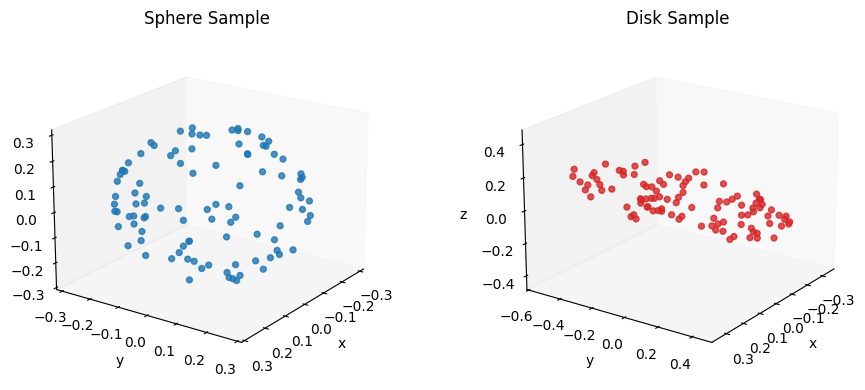

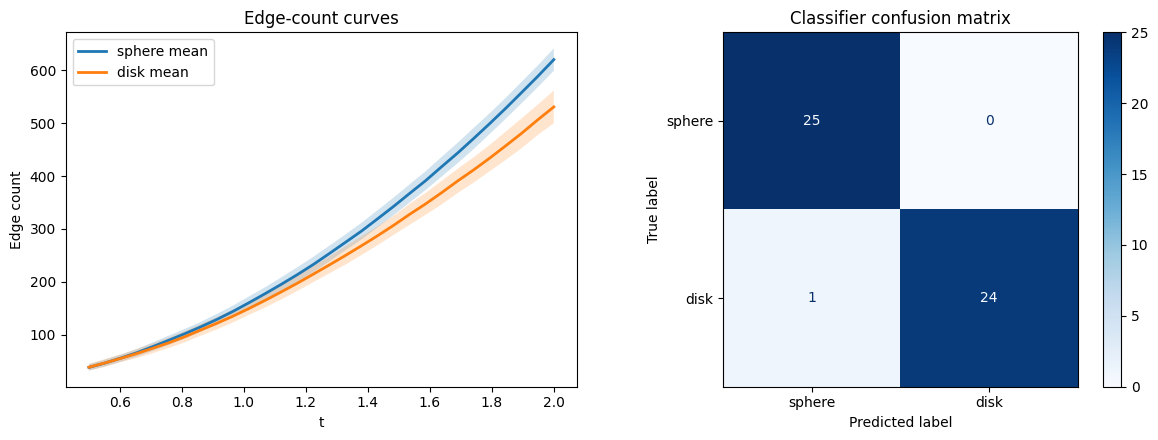

Accuracy: 0.98
              precision    recall  f1-score   support

      sphere       0.96      1.00      0.98        25
        disk       1.00      0.96      0.98        25

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [34]:
plt.style.use("default")

#INPUT
n_points = 100
n_resamples = 100
shape1 = "sphere"
shape2 = "disk"
ambient_dim = 3
t_grid = np.linspace(0.5,2,30)
shape1_kwargs = {} #Ex: {"Torus_R": 2.5, "Torus_r": 0.8},  {"cylinder_radius": 1.0, "cylinder_height": 4.0} (note that this is proporitonal since volume is being rescaled)
shape2_kwargs = {}



result = run_shape_pair_edge_curve_classifier(
    shape1=shape1,
    shape2=shape2,
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    target_volume=1.0,
    shape1_kwargs=shape1_kwargs,
    shape2_kwargs=shape2_kwargs,
)

fig = plt.figure(figsize=(10, 4))

for i, (shape, kwargs, seed, color) in enumerate([
    (result["shape1"], shape1_kwargs, 123, "tab:blue"),
    (result["shape2"], shape2_kwargs, 456, "tab:red"),
], start=1):
    X = sample_equal_volume_point_cloud(
        shape=shape,
        n_points=n_points,
        ambient_dim=result["ambient_dim"],
        target_volume=result["target_volume"],
        seed=seed,
        shape_kwargs=kwargs,
    )

    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim=2)

    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=18, alpha=0.8, color=color)
        ax.view_init(elev=20, azim=35)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape.title()} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_shape_pair_results(result)
